<a href="https://colab.research.google.com/github/lee-woonju/study-hongong-mldl/blob/main/06_3_%EC%A3%BC%EC%84%B1%EB%B6%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## KEYWORD : 차원 축소, 주성분 분석, 설명된 분산




# 차원과 차원 축소
## 차원
- 데이터가 가진 속성 = 특성 = **" 차원 "**, dimension
> 배열에서 차원은 축의 개수, 벡터의 경우 원소의 개수가 됨

## 차원 축소
- 데이터를 가장 잘 나타내는 일부 특성을 선택하여 데이터 크기를 줄이고 지도 학습 모델의 성능을 향상시킬 수 있는 방법

- [?] 비지도 학습이면서도 지도 학습의 성능을 올릴 수 있다니? 무슨말일까?
  - 데이터의 차원(특성)이 많아지면, 데이터 사이의 빈 공간이 커짐(데이터가 희소해짐)
  - 불필요하거나 의미없는 '노이즈'를 제거하여 데이터 간의 밀도 높이는 작업
  - **비지도 학습으로 지도 학습의 성능을 올린다** = 지도 학습 **모델**이 공부를 시작하기 전에 비지도 학습 **알고리즘**이 미리 데이터를 '최적의 상태'로 세팅해 준다는 뜻!

### 주성분 분석, PCA
- 대표적인 차원 축소 알고리즘
- Principal Component Analysis

# 주성분 분석
- 데이터에 있는 분산이 큰 방향을 찾는 것
- 분산 : 데이터가 널리 퍼져있는 정도
- 분산이 큰 방향 : 데이터를 잘 표현하고 있는 어떤 벡터
- 벡터 : 방향과 크기를 가진 화살표
> 이 화살표를 수학적으로 '주성분 벡터'라고 함

- 주성분(벡터)를 사용해 차원을 줄임 = 어떤 데이터를 주성분(벡터)에 직각으로 투영하면 1차원 데이터가 됨(주성분 2개에 투영하면 2차원이 됨)
> **주성분은 원본 차원과 같고, 주성분으로 바꾼 데이터는 차원이 줄어든다.**

---
### 여기까지 정리
>원본 데이터가 N개의 특성을 가지고 있을 때
>- 원본 데이터의 차원은 N개
>- 주성분 벡터 : 분산이 가장 큰 방향으로 그린 화살표
>- 주성분 벡터의 원소 개수 = 원본 특성 개수

#### 헷갈리는 포인트
'주성분 벡터'와 '주성분 벡터의 원소 개수'
- 주성분 벡터는 데이터의 특성을 가장 잘 표현한 화살표
- 차원이 2개인 원본데이터를 표현하는 벡터의 한 점은 (x1,x2) 2개의 원소로 표현가능, 차원이 100개인 원본데이터를 표현하는 벡터의 한 점은 (x1,x2,....,x99,x100) 100개의 원소로 표현
- 그래서, 주성분 벡터는 화살표 1개, 주성분 벡터의 원소는 N개
---

> 여기까지가, 첫 번째 주성분




In [36]:
!wget https://bit.ly/fruits_300_data -O fruits_300_data.npy


--2026-05-07 12:50:38--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-05-07 12:50:38--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-05-07 12:50:38--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [37]:
import numpy as np

fruits = np.load('fruits_300_data.npy')
fruits_2d = fruits.reshape(-1, 100*100)

# PCA 클래스
- 주성분 분석 알고리즘
- n_components 주성분 개수 지정

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
pca.fit(fruits_2d)

PCA(n_components=50)

- components_ 속성 : PCA 클래스가 찾은 주성분 저장

In [39]:
print(pca.components_.shape)
# (50, 10000) = (주성분개수, 원본데이터 특성 개수)

(50, 10000)


Mounted at /content/drive


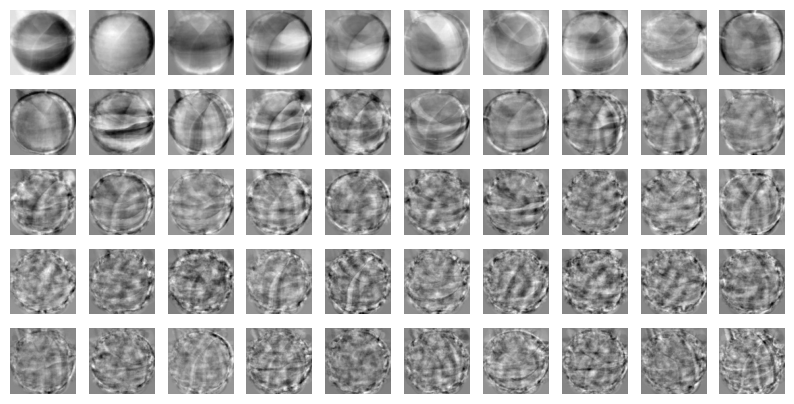

In [46]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


import importlib
import draw_fruits
importlib.reload(draw_fruits) # 수정된 파일 내용을 새로 고침

from draw_fruits import draw_fruits
draw_fruits(pca.components_.reshape(-1, 100, 100))

- 주성분 50개, 차원이 100개라 화살표보다는 **'형태'**로 나타남
- 원본 데이터를 주성분에 투영하여 10,000개의 특성을 50개로 줄일 수 있음

## transform()

In [48]:
# 원본 데이터 차원 줄이기
print(fruits_2d.shape)  # (300,10000) 10000개의 특성을 가진 300개의 이미지

fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape) # (300, 50) 50개의 특성을 가진 300개의 데이터

(300, 10000)
(300, 50)


# 원본 데이터 재구성
## inverse_transform()


In [49]:
# 50개의 차원으로 축소한 fruits_pca 데이터는 10,000개의 특성으로 복원
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


- components_ 속성에 저장되어 있어서 가능
- pca.components_ = (주성분 개수, 원본 특성 개수)
> 주의! 완전한 "**복원**"의 의미가 아님
- 데이터를 가장 잘 표현하는 50개의 주성분으로 복원한거라 **미세한 노이즈는 사라진 상태**

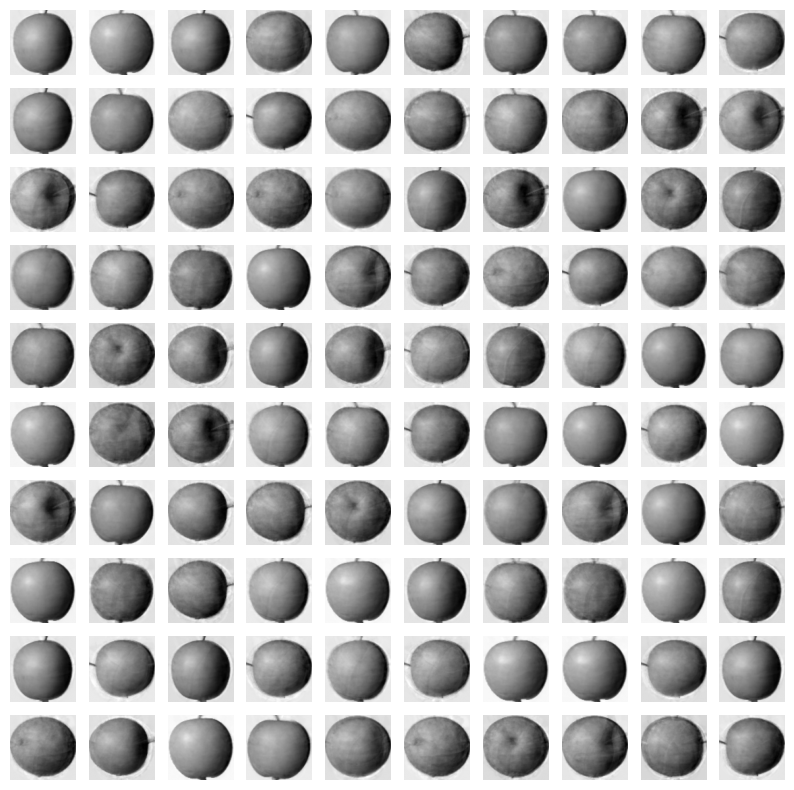

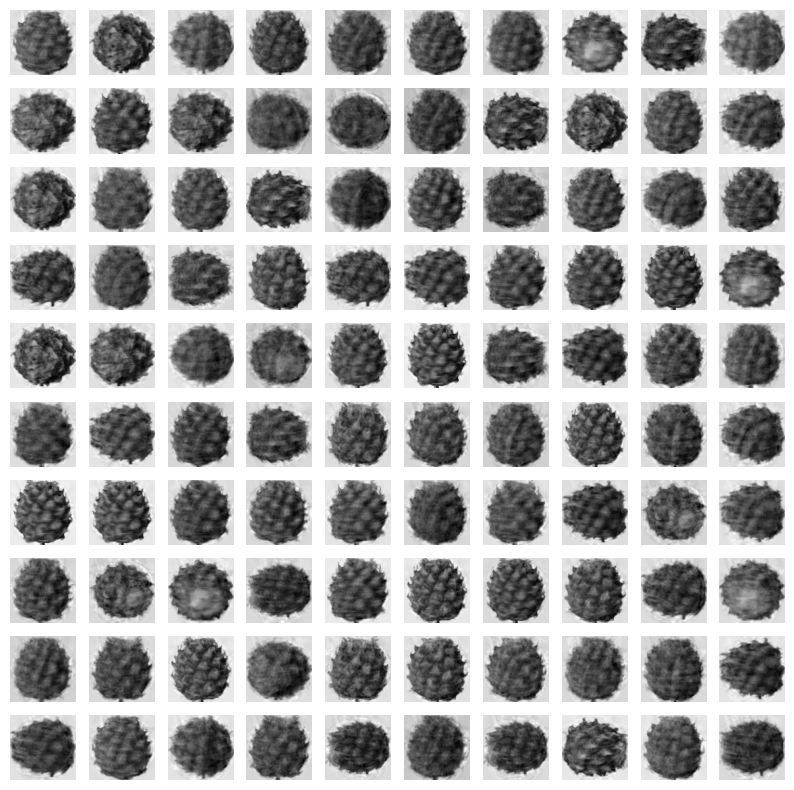

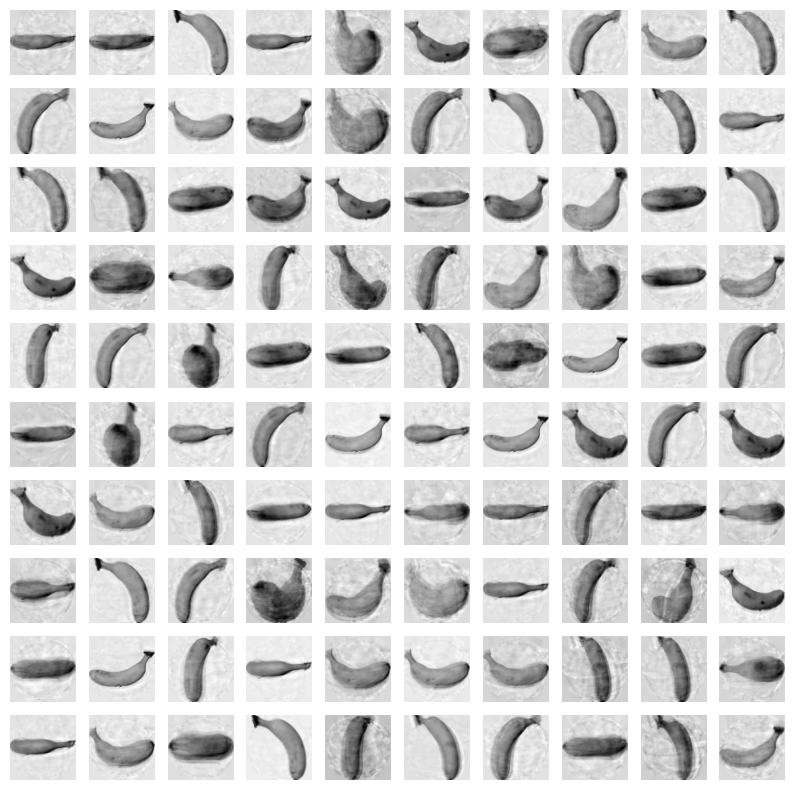

In [50]:
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)
for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print("\n")


# 설명된 분산
> 주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값
- explained_variance_ratio_ 속성에 설명된 분산 비율이 기록
- 분산 비율을 모두 더하면 np.sum()
  - 50개의 주성분으로 표현하고 있는 총 분산 비율을 얻을 수 있음

> 이게 무슨 말이냐,
> - 10000개의 특성으로 주성분을 뽑는다면 그 분산 비율의 합은 100%
> - 50개의 주성분의 분산 비율의 합 : 10000개 특성이 하던 일을 50개의 주성분으로 얼마나 잘 대변하고 있는지를 나타내는 score


In [51]:
print(np.sum(pca.explained_variance_ratio_))
# 0.921567976838393 = 92%가 넘는 분산 유지

0.921567976838393


[0.42357017 0.09941755 0.06577863 0.04031172 0.03416875 0.03281329
 0.02573267 0.02054963 0.01372276 0.01342773 0.01152146 0.00944596
 0.00878232 0.00846697 0.00693049 0.00645188 0.00578895 0.00511202
 0.00486381 0.00480346 0.00447836 0.00437315 0.00408038 0.00389472
 0.00372427 0.00359284 0.00331461 0.00317811 0.00304314 0.00303763
 0.00288916 0.00275869 0.00264899 0.00255845 0.00252081 0.00247381
 0.00239592 0.00230783 0.00222088 0.00216838 0.00213635 0.00196072
 0.00192764 0.00190397 0.00184883 0.00180655 0.00174186 0.00168244
 0.00163808 0.00160122]


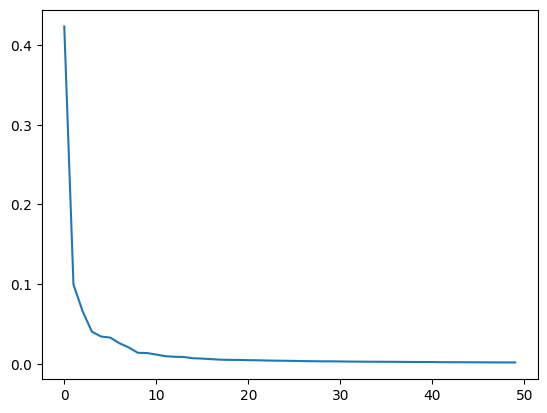

In [54]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_)
plt.show()

# 이 그래프를 보면 50개 중에서도 처음 10개의 주성분이 대부분의 분산을 표현함

# 다른 알고리즘과 함께 사용하기
## 3개의 과일 사진 '분류'를 위해 로지스틱 회귀 모델 사용
> 로지스틱 회귀 모델?!
- '회귀'가 들어가지만 사실은 '분류' 모델
- 0~1 사이의 확률을 계산해서 데이터를 분류하는 모델
- PCA로 차원을 줄인 데이터를 넣어주면, 훨씬 가볍고 빠르게 결과를 뽑아낼 수 있음!



In [55]:
# 원래 10000개의 특성을 가진 원본 데이터를 입력하면
# 특성 하나하나를 검사해서 판단
# PCA 데이터를 입력하면 단 50개의 핵심숫자(주성분 점수)만 보고 판단

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

# 지도 학습 모델이기 때문에, 타깃값 필요
target = np.array([0]*100 + [1]*100 + [2]*100)  # 100개의 0, 100개의 1, 100개의 2를 가진 타깃 데이터



- cross_validate() 교차검증 수행
  - 데이터를 여러 조각으로 나눠서, 돌아가며 학습과 테스트를 반복한 뒤 평균 점수를 내는 것
  - scores['test_score'] : 평균 점수
  - scores['fit_time'] : 학습에 걸린 시간

In [58]:
from sklearn.model_selection import cross_validate

# 10000개의 특성
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))  # 0.997
print(np.mean(scores['fit_time']))    # 2.45

# 50개의 특성
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))  # 0.997
print(np.mean(scores['fit_time']))    # 0.132

0.9966666666666667
1.5918673992156982
0.9966666666666667
0.11291012763977051


> 점수에는 차이가 없지만, 속도에서 엄청난 차이!


In [59]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

- n_components_ 에 0~1 사이의 **비율**을 입력할 수 있음
  - n_components_=0.5로 지정하면 원본 데이터에 있는 분산의 50%를 표현할 수 있음

In [60]:
# 50%를 위해 몇개의 주성분을 찾았는지 출력
print(pca.n_components_)

# 단 2개의 특성으로 분산의 50% 표현 가능

2


In [61]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [62]:
# 2개의 특성 교차검증 점수
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))  # 0.99
print(np.mean(scores['fit_time']))    # 0.03

0.99
0.034818506240844725


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


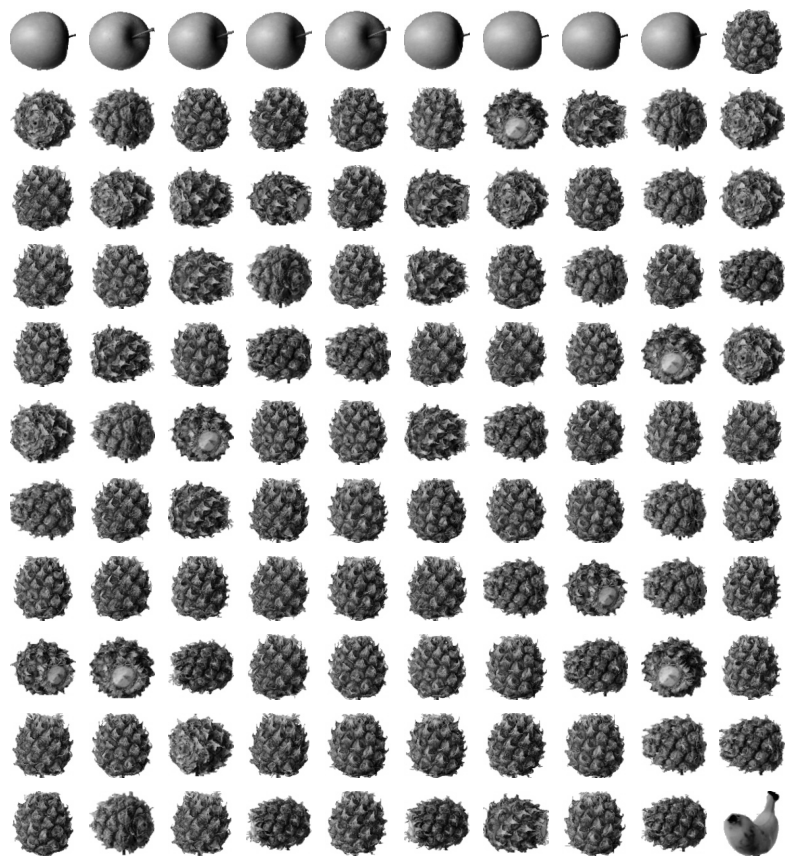

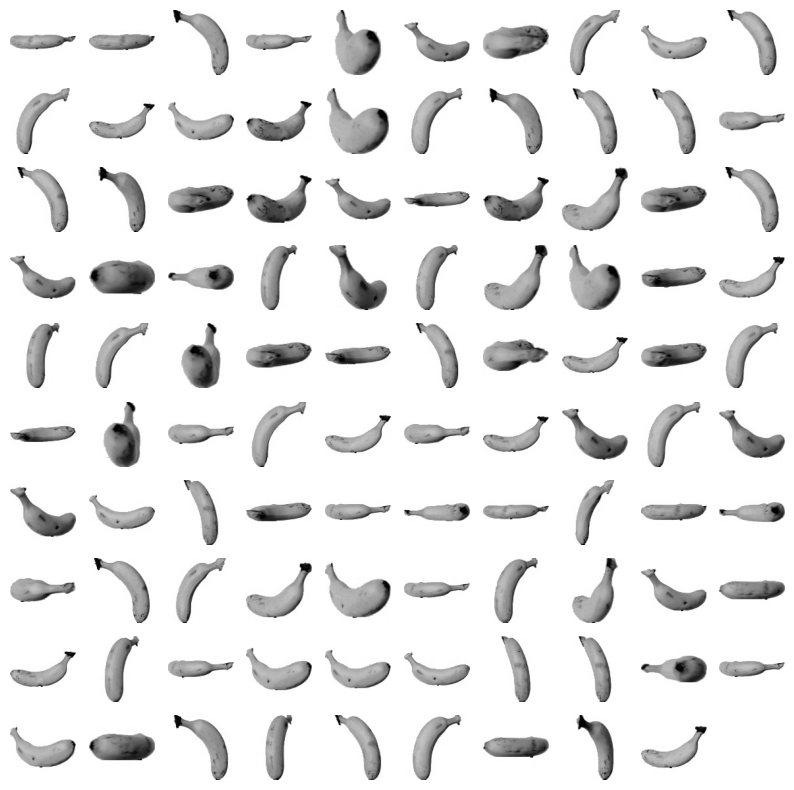

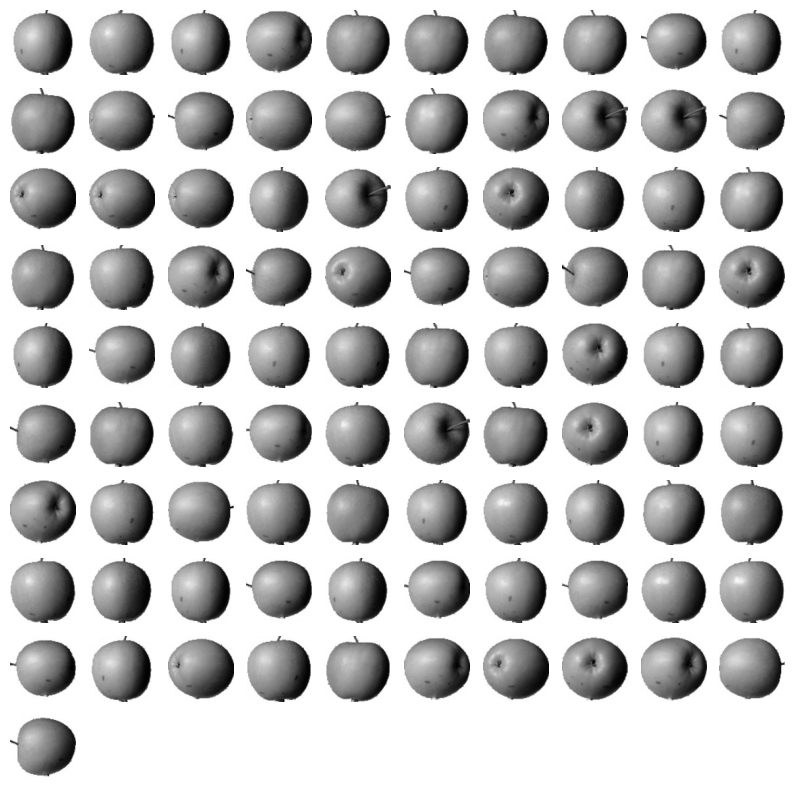

In [64]:
# k-평균 알고리즘으로 클러스터 찾기
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)    # n_clusters_ 클러스터 개수
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))


for label in range(0,3):
  draw_fruits(fruits[km.labels_ == label])
  print("\n")

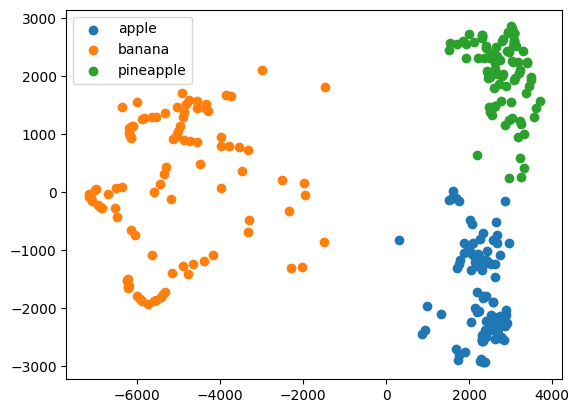

In [65]:
# 3개 이하로 차원을 줄이면 화면에 출력하기가 쉬움
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:, 0], data[:, 1])
plt.legend(['apple', 'banana', 'pineapple'])
plt.show()

# [요약]
> 주성분 분석 : 원본 데이터를 주성분에 투영하여 '새로운 특성'을 만들어내는 것
* 주요 용어
  - 주성분 벡터 : 원본데이터의 분산이 가장 큰 방향
  - 설명된 분산 : 주성분이 원본 데이터를 얼마나 잘 표현하는지에 대한 점수
* PCA 주요 속성
  - n_components_
    - 정수입력 : 주성분 개수
    - 실수입력(0~1) : 설명된 분산 비율
  - pca.components_ : PCA가 찾은 주성분 벡터 저장
    - (주성분 개수, 원본 특성 개수)
  - pca.explained_variance_ratio : 각 주성분이 원본 데이터의 분산을 얼마나 대변하는지 나타내는 비율
    - np.sum()으로 합치면 전체 재현도(score) 확인 가능
* PCA 주요 메서드
  - fit() : 학습. 주성분(압축 기준) 찾기
  - transform() : 변환. 학습된 기준으로 데이터를 축소된 차원으로 변환
  - inverse_transform() : 압축된 데이터를 원본 차원으로 복원(노이즈가 제거된 상태)

